In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
df = pd.read_csv('dataset_clean.csv')



In [2]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)



In [3]:
print(f"Train: {len(train_df)} rows")
print(train_df['label'].value_counts())
print(f"\nTest: {len(test_df)} rows")
print(test_df['label'].value_counts())

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

Train: 9410 rows
label
Anxiety         3181
Depression      3118
SuicideWatch    3111
Name: count, dtype: int64

Test: 2353 rows
label
Anxiety         796
Depression      779
SuicideWatch    778
Name: count, dtype: int64


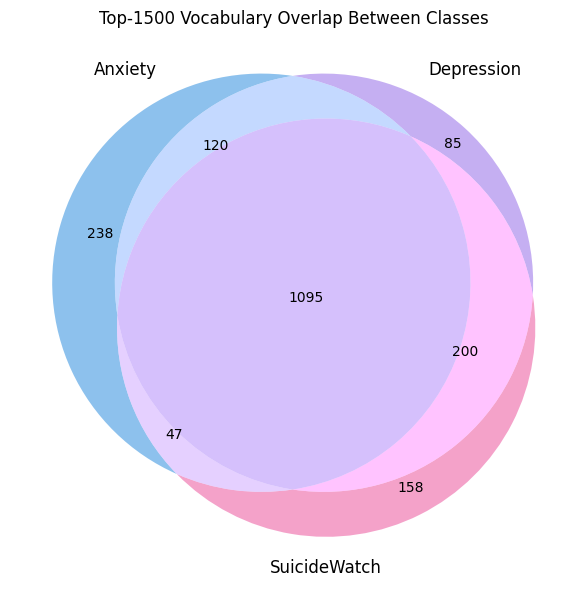

In [11]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def get_vocab(df, label, top_n=500):
    corpus = df[df['label'] == label]['clean_text']
    vec = CountVectorizer(max_features=top_n)
    vec.fit(corpus)
    return set(vec.get_feature_names_out())

anxiety_vocab    = get_vocab(train_df, 'Anxiety',      top_n=1500)
depression_vocab = get_vocab(train_df, 'Depression',   top_n=1500)
suicide_vocab    = get_vocab(train_df, 'SuicideWatch', top_n=1500)

fig, ax = plt.subplots(figsize=(7, 6))
venn3(
    [anxiety_vocab, depression_vocab, suicide_vocab],
    set_labels=('Anxiety', 'Depression', 'SuicideWatch'),
    set_colors=('#4299E1', '#9F7AEA', '#ED64A6'),
    alpha=0.6,
    ax=ax
)
ax.set_title('Top-1500 Vocabulary Overlap Between Classes', fontsize=12)
plt.tight_layout()
plt.savefig('vocab_overlap_venn.png', dpi=150, bbox_inches='tight')
plt.show()
